In [37]:
import matplotlib.pyplot as plt
import sympy as sp
from sympy import symbols, I, Abs
from sympy.physics.control import *
import numpy as np
import matplotlib.pyplot as plt

# Funções Auxiliares

In [9]:
s, k = sp.symbols('s k')
ganho = k

## Função para receber coeficientes e transformar em polinômio

In [ ]:
def polinomio(entrada):
    coeficientes = entrada.strip().split()  # Transforma a entrada em uma lista de strings e remove espaços extras
    coeficientes.reverse() # Inverte a lista
    lista_polinomio = []
    
    # Percorre de trás para frente para começar pelo maior expoente
    for exp in range(len(coeficientes) - 1, -1, -1):
        coef = coeficientes[exp]
        
        # Pula coeficientes que são zero
        if coef == "0":
            continue
            
        # Formata o termo dependendo do expoente
        if exp > 1:
            termo = f"{coef}*s**{exp}"
        elif exp == 1:
            termo = f"{coef}*s"
        else:
            termo = f"{coef}"
            
        lista_polinomio.append(termo)
        
    return " + ".join(lista_polinomio)

# Teste do código
pol = polinomio(input("Digite os coeficientes separados por espaço: "))
print(pol)


1*s**3 + 2*s + 6


## Função para calcular passo 4

# Passo a passo LGR

In [24]:
print("Forneça os coeficientes da função G(s)...")
numerador_G = polinomio(input("Digite os coeficientes do numerador: "))
denominador_G = polinomio(input("Digite os coeficientes do denominador: "))

numerador_G = sp.parse_expr(numerador_G, local_dict={'s': s})
denominador_G = sp.parse_expr(denominador_G, local_dict={'s': s})

G = TransferFunction(numerador_G, denominador_G, s)
G

Forneça os coeficientes da função G(s)...


TransferFunction(2*s + 2, s**2 + 13*s, s)

In [25]:
print("Forneça os coeficientes da função H(s)...")
numerador_H = polinomio(input("Digite os coeficientes do numerador: "))
denominador_H = polinomio(input("Digite os coeficientes do denominador: "))

numerador_H = sp.parse_expr(numerador_H, local_dict={'s': s})
denominador_H = sp.parse_expr(denominador_H, local_dict={'s': s})

H = TransferFunction(numerador_H, denominador_H, s)
H

Forneça os coeficientes da função H(s)...


TransferFunction(1, s, s)

In [26]:
ft = Series(G, H).doit()
ft

TransferFunction(2*s + 2, s*(s**2 + 13*s), s)

## Passo 01 - Escrever polinômio característico

In [27]:
print("1 + K*")
ft

1 + K*


TransferFunction(2*s + 2, s*(s**2 + 13*s), s)

## Passo 02 = Fatorar polinômio

In [29]:
fatorado = sp.factor(ft)
print("1 + K*")
fatorado

1 + K*


TransferFunction(2*(s + 1), s**2*(s + 13), s)

# Passo 3 - Polos e Zeros de malha aberta

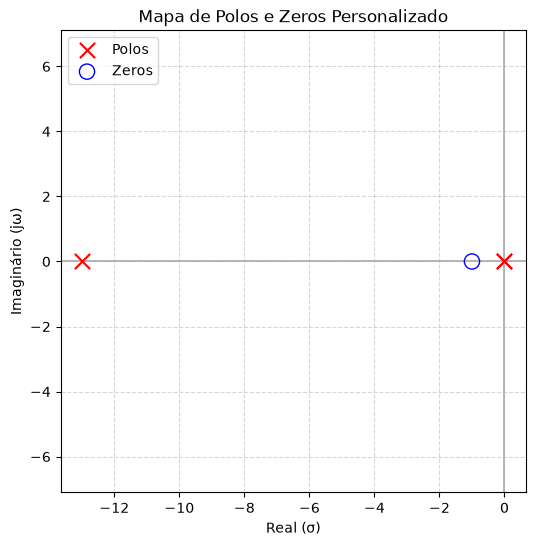

In [40]:
# 1. Extrai as coordenadas numéricas reais e imaginárias do SymPy
zeros, poles = pole_zero_numerical_data(fatorado)

# 2. Cria o gráfico nativo no Matplotlib
fig, ax = plt.subplots(figsize=(6, 6)) # Modificar limites 

# Desenha os Polos (X vermelho) e Zeros (O azul)
ax.scatter([p.real for p in poles], [p.imag for p in poles], 
           marker='x', color='red', s=120, label='Polos', zorder=3)
ax.scatter([z.real for z in zeros], [z.imag for z in zeros], 
           marker='o', color='blue', facecolors='none', s=120, label='Zeros', zorder=3)

ax.axhline(0, color='darkgray', linewidth=1.2) # Linha do Eixo Real
ax.axvline(0, color='darkgray', linewidth=1.2) # Linha do Eixo Imaginário

# Configurações visuais finais do gráfico
ax.grid(True, linestyle='--', alpha=0.5)
ax.set_xlabel('Real (σ)')
ax.set_ylabel('Imaginário (jω)')
ax.set_title('Mapa de Polos e Zeros Personalizado')
ax.axis('equal') # Garante proporção 1:1 perfeita no plano complexo
ax.legend()

plt.show()

## Passo 04 - Assinalar segmentos do eixo real LGR

In [ ]:
# 2. Cria o gráfico nativo no Matplotlib
fig, ax = plt.subplots(figsize=(6, 6)) # Modificar limites 

# Adiciona linhas LGR



# Desenha os Polos (X vermelho) e Zeros (O azul)
ax.scatter([p.real for p in poles], [p.imag for p in poles], 
           marker='x', color='red', s=120, label='Polos', zorder=3)
ax.scatter([z.real for z in zeros], [z.imag for z in zeros], 
           marker='o', color='blue', facecolors='none', s=120, label='Zeros', zorder=3)

ax.axhline(0, color='darkgray', linewidth=1.2) # Linha do Eixo Real
ax.axvline(0, color='darkgray', linewidth=1.2) # Linha do Eixo Imaginário

# Configurações visuais finais do gráfico
ax.grid(True, linestyle='--', alpha=0.5)
ax.set_xlabel('Real (σ)')
ax.set_ylabel('Imaginário (jω)')
ax.set_title('Mapa de Polos e Zeros Personalizado')
ax.axis('equal') # Garante proporção 1:1 perfeita no plano complexo
ax.legend()

plt.show()